# GMFD Analysis
### July 7, 2026

# Initialization

In [36]:
import os
from pathlib import Path
from dotenv import load_dotenv, find_dotenv
import xarray as xr

import geopandas as gpd
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils
import importlib
importlib.reload(analysis_utils)

<module 'analysis_utils' from '/home/emily_zuetell/projects/poreallas/scripts/analysis_utils.py'>

In [3]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

In [5]:
_polygons = (
    gpd.read_parquet(IMPACT_REGION_POLYGONS)
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

socioeconomics =  xr.open_zarr(SOCIOECONOMICS_URI)
socioeconomics = socioeconomics.sel(year = 2026)[['pop0to4', 'pop5to64', 'pop65plus', 'pop', 'gdppc', 'iso3']]

In [ ]:
# IR Climate Data
forecast_gmfd = xr.open_zarr(os.path.join(DATA_DIR, "daily_forecast_GMFD_tas.zarr"))
reanlysis_gmfd = xr.open_zarr(os.path.join(DATA_DIR, "daily_reanalysis_GMFD_tas.zarr"))
#Effects
effect_gmfd = xr.open_datatree(os.path.join(DATA_DIR, EFFECTS_URI), consolidated = False)

# CSV Output

In [ ]:
def gdp_quartile(da_gdp):
    quartile_labels = pd.qcut(da_gdp.values, q=4, labels=['low', 'mid-low', 'mid-high', 'high'])
    return xr.DataArray(
        quartile_labels.astype(str),
        dims=da_gdp.dims,
        coords=da_gdp.coords,
        name='gdp_quartile'
    )

#Load age-weighted data
impact = analysis_utils.compute_impact(effect_gmfd, socioeconomics, ensemble = True, baseline_period=baseline_period, hotonly = False, rate = True, age_weight = True)
_polygons_impact = analysis_utils.xarray_to_gpd(impact.mean(dim = 'number').sum(dim = 'month'), _polygons)
df_country = _polygons_impact[['age_weighted_effect', 'ISO']].groupby('ISO').sum()
df_country = df_country.rename(columns={'age_weighted_effect': 'age_weighted_impact'})

#Load data for all age cohorts
for cohort in ['age0to4', 'age5to64', 'age65plus']:
    impact = analysis_utils.compute_impact(effect_gmfd, socioeconomics, ensemble = True, baseline_period=baseline_period, hotonly = False, rate = True, age_weight = False, cohort = cohort)
    _polygons_impact = analysis_utils.xarray_to_gpd(impact.mean(dim = 'number').sum(dim = 'month'), _polygons)
        
    col = f'{cohort}_effect'
    col_i = f'{cohort}_impact'
    df_country[col_i] = _polygons_impact[[col, 'ISO']].groupby('ISO').sum()

#World Bank Income Rankings
#income_class = pd.read_csv(os.path.join(DATA_DIR, "income_class_2025.csv")) 
#out_df = df_country.merge(income_class, how = 'left', left_on = 'ISO', right_on = 'Code')

#Pop-weighted GDP by Country
socioeconomics = socioeconomics.load()
gdp_quartile_df = gdp_quartile(
    socioeconomics.groupby('iso3').map(lambda ds: ds['gdppc'].weighted(ds['pop']).mean())
).to_dataframe()

out_df = df_country.reset_index().merge(gdp_quartile_df.reset_index(), how = 'left', left_on = 'ISO', right_on = 'iso3')
out_df.to_csv("2605_impact_country_gdppc.csv")

<Axes: >

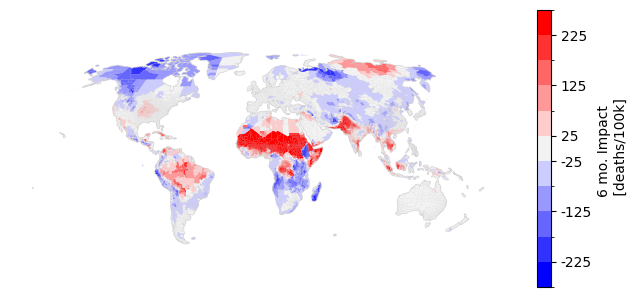

In [105]:
analysis_utils.plot_single(
    _polygons_impact,
    col='age65plus_effect',
    rate=True,
    cm = 'bwr',
    sup_title=f"",
    cbar_label= '6 mo. Impact \n [deaths/100k]',
    cbar_location='right'
)

# Postcard Map

In [8]:
postcard_ir = xr.open_zarr("/home/emily_zuetell/projects/poreallas/scripts/data/2607_year_ir_ssp245.zarr")
anomaly = xr.open_zarr('/home/emily_zuetell/projects/poreallas/scripts/data/2607_anomaly_ir.zarr')

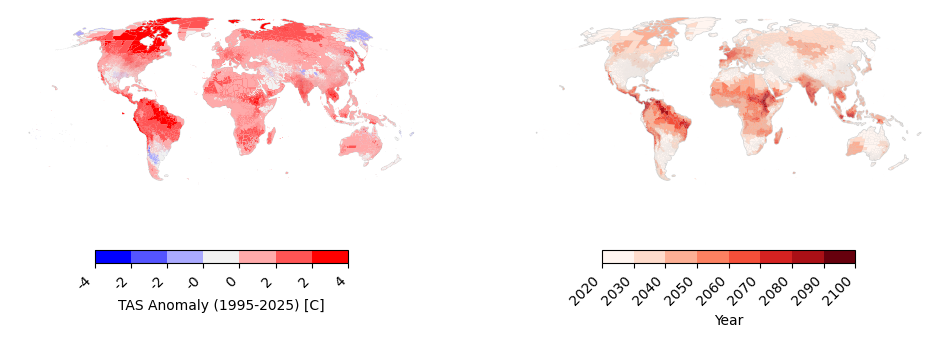

In [13]:
_polygons_anomaly = analysis_utils.xarray_to_gpd(anomaly['t2m'], _polygons, robinson = True)

fig, axs = plt.subplots(1,2, figsize = (12,5))
analysis_utils.plot_single(
    _polygons_anomaly,
    col='t2m',
    rate=True,
    cm = 'bwr',
    sup_title=f"",
    cbar_label= 'TAS Anomaly (1995-2025) [C]',
    ax = axs[0],
    cbar_location='bottom'
)

_polygons_postcard = analysis_utils.xarray_to_gpd(postcard_ir['crossing_year'], _polygons, robinson = True)

analysis_utils.plot_single(
    _polygons_postcard,
    col='crossing_year',
    rate=True,
    cm = 'Reds',
    vmin = 2020,
    vmax = 2100,
    cbar_label= 'Year',
    ax = axs[1],
    cbar_location='bottom'
)

fig.savefig("2607_combined_anomaly_postcard", dpi=600, bbox_inches="tight")

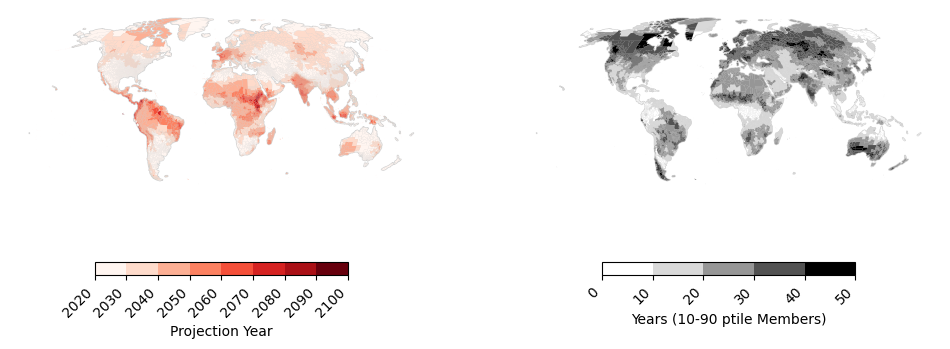

In [161]:
_polygons_postcard = _polygons.merge(
    postcard_ir['crossing_year'].to_dataframe().reset_index(),
    on="region",
).cx[:, -60:90].to_crs('ESRI:54030')

fig, axs = plt.subplots(1,2, figsize = (12,6))
analysis_utils.plot_single(
    _polygons_postcard,
    col='crossing_year',
    rate=True,
    cm = 'Reds',
    vmin = 2020,
    vmax = 2100,
    cbar_label= 'Projection Year',
    ax = axs[0],
    cbar_location='bottom'
)

postcard_data =postcard_ir['ci_width_95']
_polygons_postcard = _polygons.merge(
    postcard_data.to_dataframe().reset_index(),
    on="region",
).cx[:, -60:90].to_crs('ESRI:54030')

analysis_utils.plot_single(
    _polygons_postcard,
    col='ci_width_95',
    rate=True,
    cm = 'Grays',
    vmin = 0,
    vmax = 50,
    cbar_label= 'Years (10-90 ptile Members)',
    ax = axs[1],
    cbar_location='bottom'
)

fig.savefig("2607_combined_spread_postcard", dpi=600, bbox_inches="tight")

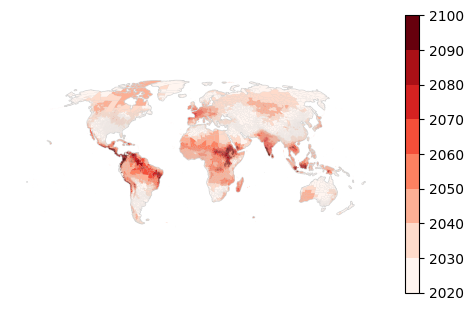

In [ ]:
postcard_data =postcard_ir
_polygons_postcard = _polygons.merge(
    postcard_data.to_dataframe().reset_index(),
    on="region",
).cx[:, -60:90].to_crs('ESRI:54030')

fig, ax = plt.subplots(figsize = (6,6))
analysis_utils.plot_single(
    _polygons_postcard,
    col='crossing_year',
    rate=True,
    cm = 'Reds',
    vmin = 2020,
    vmax = 2100,
    ax = ax,
    cbar_label= '',
)

plt.rcParams['hatch.linewidth'] = 0.05
_polygons_postcard[_polygons_postcard['ci_10'] > 2050].plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.02)

fig.savefig("2607_postcard_2050CI", dpi=600, bbox_inches="tight")

# Diagnostic Panel - Dose Response 

In [38]:
#Intermediate Betas/MMT from Project.Py
betas_mmt = xr.open_zarr(os.path.join(DATA_DIR, "beta_mmt_GMFD.zarr"))

In [39]:
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec

import cartopy.crs as ccrs
from scipy.interpolate import interp1d
from shapely import box

import diagnostic_utils

### Analysis Options ###
rate = True # Mortality Rate vs Total Deaths
hotonly = False # Hot-Only Deaths
age_weight = False #Proportional Age-weighting vs single age group
density_hist = False #Controls daily data histograms (not computation normalization)

### Region Selection ###
region_filters = [
    "PAK.2.5.27",
    "IND.16.203.735",
    "BRA.7.804.1862",
    "IND.29.439.1743",
    "CHN.11.109.767",  # set to None for global
    "COD.3.15.51",
    "THA.76.909.5787",
    "HRV.R4acd3465906d6fba",
    "EGY.8",
    "BRA.9.R7ae8d9b7a4e0454f",
    "ZMB.9.67",
    "USA.14.608",
]

region_filter = "EGY.8"

### Load Climate Data ###
forecast_local = forecast_gmfd['tas'].sel(time=slice('2026-07-01', '2026-10-31'))
reanalysis_local = reanlysis_gmfd['tas'].sel(time=slice('2016-07-01', '2016-10-31'))

combined = np.concat([forecast_local.sel(region = region_filter).values.flatten(), reanalysis_local.sel(region = region_filter).values.flatten()])
xmin, xmax = np.percentile(combined, [1, 100])

# Compute Impact
projected = effect_gmfd
regional_sum = analysis_utils.compute_impact(projected, socioeconomics, baseline_period= baseline_period, hotonly = hotonly, rate = rate, age_weight = age_weight)

#Get Months
months = regional_sum.month.values[1:]

# Compute Cumulative Effect
cdf_data, max_cdf = diagnostic_utils.compute_cumulative_effect(forecast_local, reanalysis_local, region_filter, months, hotonly = hotonly)

ModuleNotFoundError: No module named 'diagnostic_utils'

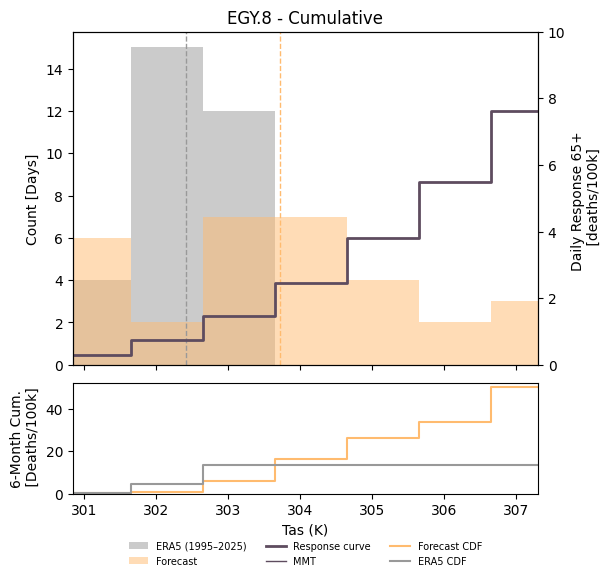

In [16]:


#Histogram

b_color = "#999999"
f_color = "#ffbb6f"
r_color = "#5e4c5f"

fig, (ax_hist, ax_cdf) = plt.subplots(
    2, 1, sharex=True, figsize=(6, 6),
    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08}
)
forecast_local_month = forecast_local.sel(region = region_filter)
reanalysis_local_month = reanalysis_local.sel(region = region_filter)

ref_vals = betas_mmt['mmt'].sel(region=region_filter).sel(age_cohort='age65plus') + 273.15
betas = betas_mmt['beta_hotonly'] if hotonly else betas_mmt['beta']
da_temp_bins = betas.sel(region=region_filter).sel(age_cohort='age65plus')
da_temp_bins['tas_bin'] = da_temp_bins['tas_bin'] + 273.15

# Density histograms on hidden twin axis
bins = da_temp_bins.coords['tas_bin']
ax_hist.hist(reanalysis_local_month.values.flatten(), bins=bins, alpha=0.5, label="ERA5 (1995–2025)", density=density_hist, color=b_color)
ax_hist.hist(forecast_local_month.values.flatten(), bins=bins, alpha=0.5, label="Forecast", density=density_hist, color=f_color)
ax_hist.axvline(forecast_local_month.values.flatten().mean(), color=f_color, linewidth=1, linestyle='--')
ax_hist.axvline(reanalysis_local_month.values.flatten().mean(), color=b_color, linewidth=1, linestyle='--')
ax_hist.set_ylabel("Count [Days]")
ax_hist.set_xlim(xmin, xmax)

# Response curve on the primary (left) axis
ax_hist2 = ax_hist.twinx()
ax_hist2.step(da_temp_bins.coords['tas_bin'], da_temp_bins.values, where='pre', color=r_color, linewidth=2, label="Response curve")
ax_hist2.axvline(ref_vals.values, color=r_color, linewidth=1, label="MMT")
ax_hist2.set_ylabel("Daily Response 65+ \n [deaths/100k]")
ax_hist2.set_ylim(0, 10)
ax_hist2.set_xlim(xmin, xmax)

# Weighted CDFs in their own subplot below
era5_centers, era5_cdf, fc_centers, fc_cdf = cdf_data

ax_cdf.set_ylabel("6-Month Cum.\n [Deaths/100k]")
ax_cdf.set_ylim(0, max_cdf+2)
ax_cdf.set_xlim(xmin, xmax)
ax_cdf.set_xlabel("Tas (K)")
ax_cdf.step(fc_centers, fc_cdf, where='post', color=f_color, label="Forecast CDF")
ax_cdf.step(era5_centers, era5_cdf, where='post', color=b_color, label="ERA5 CDF")

#Legend
handles = (ax_hist.get_legend_handles_labels()[0]
            + ax_hist2.get_legend_handles_labels()[0]
            + ax_cdf.get_legend_handles_labels()[0])
labels = (ax_hist.get_legend_handles_labels()[1]
            + ax_hist2.get_legend_handles_labels()[1]
            + ax_cdf.get_legend_handles_labels()[1])
ax_cdf.legend(handles, labels, fontsize=7, loc='upper center',
                bbox_to_anchor=(0.5, -0.35), ncol=3, frameon=False)
ax_hist.set_title(f'{region_filter} - Cumulative')
fig.savefig(f'response_diagnostic_{region_filter}_2607.png', dpi=600, bbox_inches="tight")

# MMT Map

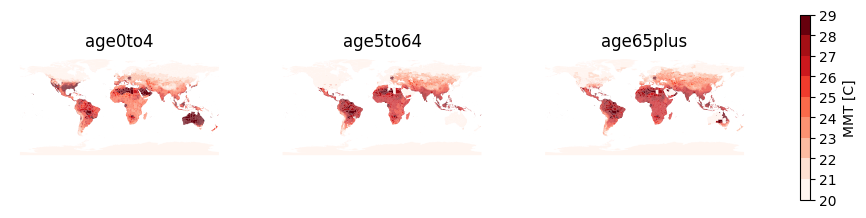

In [36]:
import matplotlib.colors as mcolors
edgecolor=None
linewidth=0
vmin = 20
vmax = 29

cm = 'Reds'
step = analysis_utils.get_step(vmax - vmin)
bounds = np.arange(vmin, vmax + step, step)
cmap = plt.get_cmap(cm, len(bounds) - 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)

fig, axs = plt.subplots(1,3, figsize=(12, 4))
i = 0
for ag in ['age0to4', 'age5to64', 'age65plus']:
    ax = axs[i]

    mmt_map =betas_mmt['mmt'].sel(age_cohort = ag)
    _polygons_mmt = _polygons.merge(
        mmt_map.to_dataframe().reset_index(),
        on="region",
    )

    _polygons_mmt.plot(
        column='mmt',
        legend=False,
        ax=ax,
        cmap=cmap,
        norm=norm,
        edgecolor=edgecolor,
        linewidth=linewidth,
    )
    ax.set_axis_off()
    ax.set_title(ag)
    i = i+1

cbar_label = f'MMT [C]'
fig.colorbar(sm, ax=axs, location='right', shrink=0.6, label=cbar_label)
fig.savefig("mmt_allages.png", dpi=600, bbox_inches="tight")

# Mortality Rate Levels

In [54]:
_baseline = (
    projected["/baseline"]["effect"]
    .sel(time=baseline_period)
    .groupby("time.month")
    .mean()
)

_forecast = (
    projected["/forecast"]["effect"].mean(dim = 'number').groupby("time.month").mean()
)
#impact = _baseline.sel(month = [5, 6, 7, 8, 9, 10])
impact = _forecast
impact.name = "impact"
impact.attrs["long_name"] = "Temperature mortality impact"
impact.attrs["units"] = "Deaths per 100,000 people"
impact.attrs['hotonly'] = False
regional_sum = analysis_utils.pop_weight_sum(impact, socioeconomics, rate=rate, age_weight=age_weight)

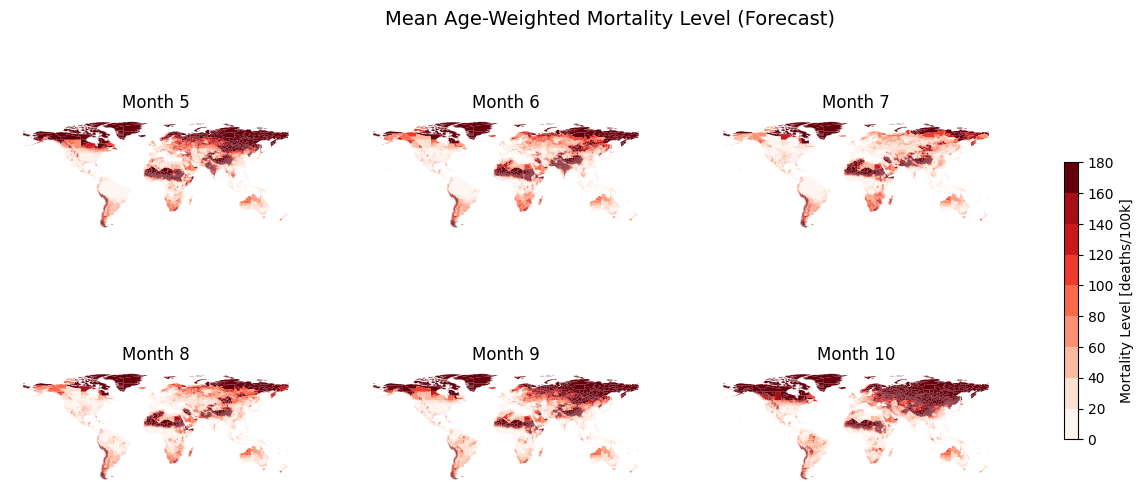

In [55]:
baseline = False
gmfd = True
da = regional_sum
gdf = _polygons.merge(
    da.to_dataframe().reset_index(),
    on="region",
)

label = 'After' if gmfd else 'Before'
label_s = 'baseline' if baseline else 'forecast'
date_s = "2605"

fig = analysis_utils.plot_monthly(
    gdf,
    col='age_weighted_effect',
    vmin = 0,
    vmax = 180,
    rate=True,
    sup_title=f"Mean Age-Weighted Mortality Level (Forecast)",
    save_title=f'{date_s}_mean_rate_agwt_level_{label_s}.png',
    cm='Reds',
    cbar_label= 'Mortality Level [deaths/100k]',
)

## Impact Percentiles

In [17]:
#Differences with old (not GMFD data) (hist with response curve)
impact_gmfd = analysis_utils.compute_impact(effect_gmfd, socioeconomics, ensemble = True, baseline_period=baseline_period, hotonly = False, rate = True, age_weight = True)

## Impact

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


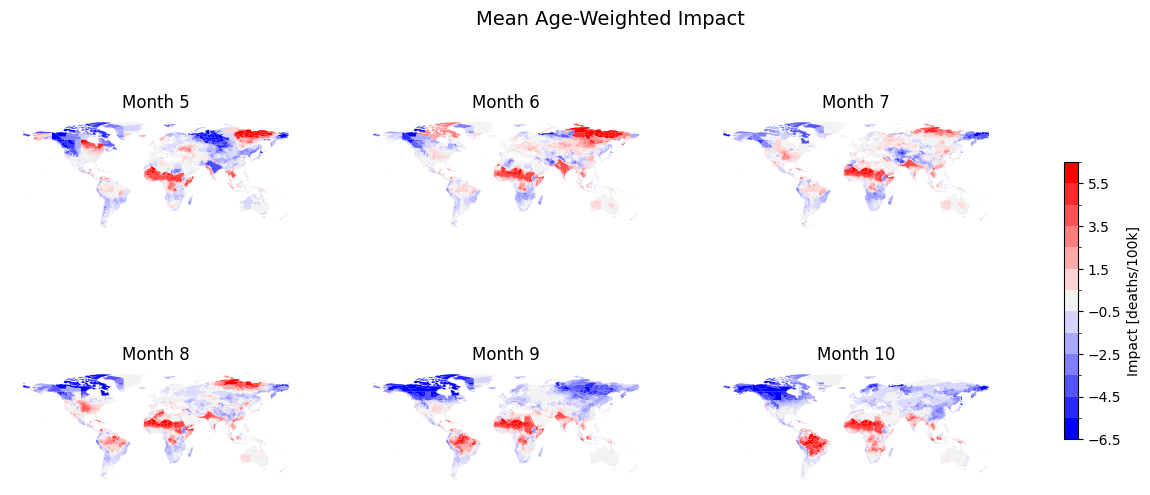

In [9]:
gmfd = True
da = impact_gmfd if gmfd else impact_og
_polygons_num = compute_stats(da, polygon=True)
gdf = _polygons_num

label = 'After' if gmfd else 'Before'
label_s = 'gmfd' if gmfd else 'og'
date_s = "2605"

fig = analysis_utils.plot_monthly(
    gdf,
    col='mean',
    rate=True,
    sup_title=f"Mean Age-Weighted Impact",
    save_title=f'{date_s}_mean_rate_agwt.png',
    cm='bwr',
)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


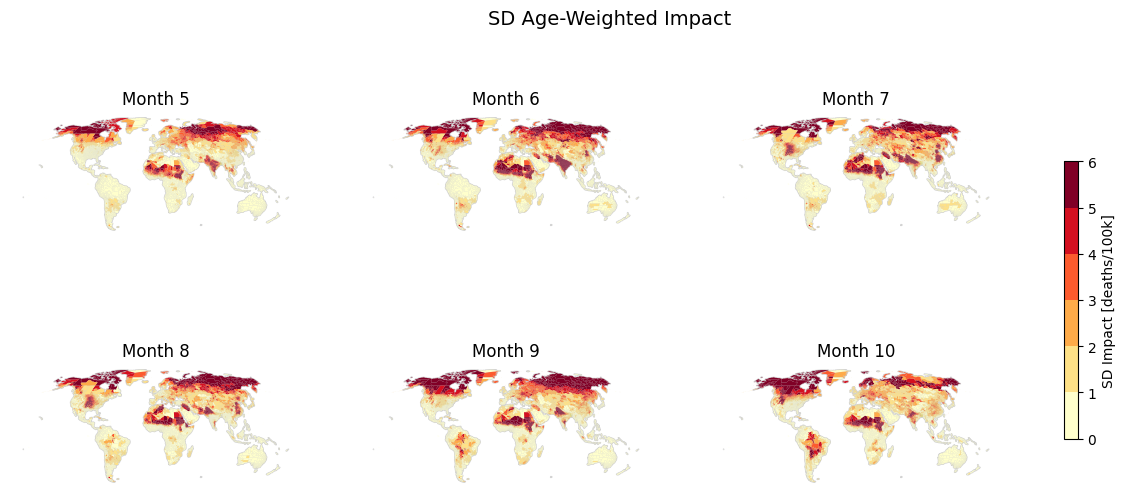

In [37]:
gmfd = True
gdf = analysis_utils.compute_stats(impact_gmfd, dim = 'number', polygon=_polygons)

date_s = "2605"
#ToDo: Fix monthly plotting
fig = analysis_utils.plot_monthly(
    gdf,
    col='std',
    vmin = 0,
    vmax = 6,
    sup_title=f"SD Age-Weighted Impact",
    save_title=f'{date_s}_sd_rate_agwt.png',
    cm="YlOrRd",
    cbar_label= 'SD Impact [deaths/100k]',
)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


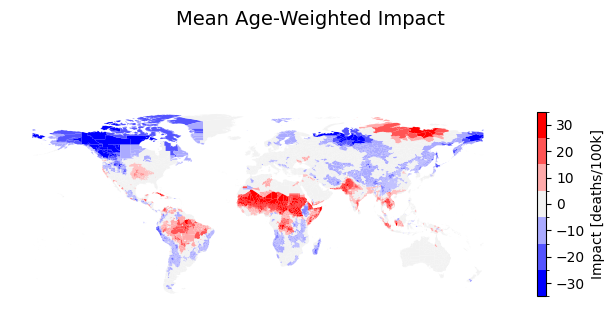

In [11]:
gmfd = True
da = impact_gmfd if gmfd else impact_og
_polygons_num = compute_stats(da, polygon=True)
gdf = _polygons_num

label = 'After' if gmfd else 'Before'
label_s = 'gmfd' if gmfd else 'og'

fig = analysis_utils.plot_cumulative(
    gdf,
    col='mean',
    rate=True,
    sup_title=f"Mean Age-Weighted Impact",
    save_title=f'{label_s}_mean_rate_agwt.png',
    cm='bwr',
)

## Change in Impact (w/ GMFD)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: divide by zero encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


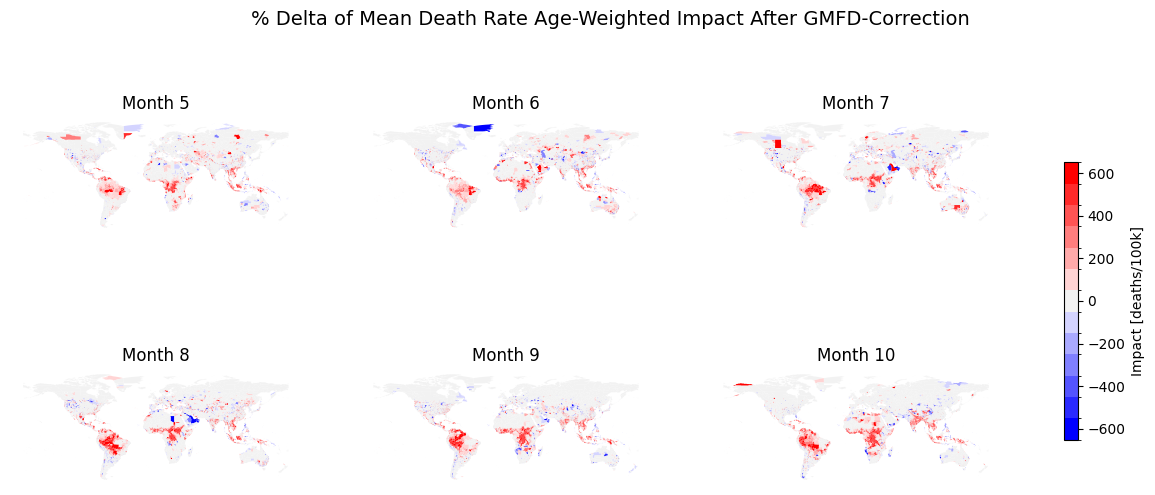

In [13]:
rate = True
pct_change = True

if pct_change:
    diff = 100*(impact_gmfd-impact_og)/np.abs(impact_og)
else:
    diff = (impact_gmfd-impact_og)
_polygons_num = compute_stats(diff, polygon = True)   
gdf = _polygons_num

metric = "% Delta" if pct_change else "Delta"
metric_s = "pct_delta" if pct_change else "delta"
units = "[deaths/100k]" if rate else "[num. deaths]"
label = 'Death Rate' if rate else "Deaths"
label_s = 'rate' if rate else "deaths"

sup_title = f'{metric} of Mean {label} Age-Weighted Impact After GMFD-Correction'
save_title = f'{metric_s}_gmfd_mean_{label_s}_agwt.png'

fig = analysis_utils.plot_monthly (gdf, 'mean', rate = True, c_title = "", sup_title = sup_title, save_title = save_title)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


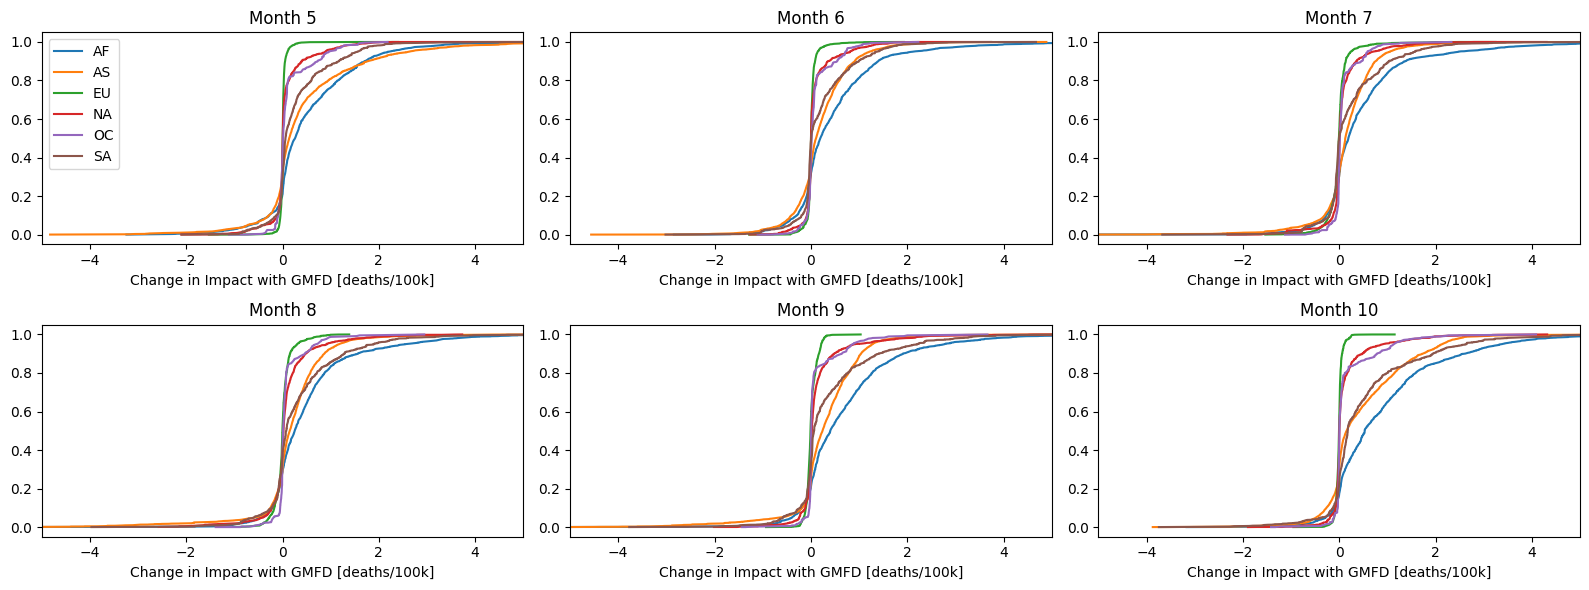

In [16]:
import pycountry_convert as pc
import matplotlib.pyplot as plt

def iso_to_continent(iso3):
    try:
        iso2 = pc.country_alpha3_to_country_alpha2(iso3)
        return pc.country_alpha2_to_continent_code(iso2)
    except:
        return None
rate = True
pct_change = False

if pct_change:
    diff = 100*(impact_gmfd-impact_og)/np.abs(impact_og)
else:
    diff = (impact_gmfd-impact_og)
_polygons_num = compute_stats(diff, polygon = True)   
gdf = _polygons_num

gdf['continent'] = gdf['ISO'].apply(iso_to_continent)

months = sorted(gdf['month'].unique())
fig, axes = plt.subplots(2, 3, figsize=(16, 6))

for ax, month in zip(axes.flat, months):
    monthly = gdf[gdf['month'] == month][['region', 'ISO', 'continent', 'mean']].merge(
        socioeconomics[['region', 'pop']].to_dataframe().reset_index(), on='region'
    )

    for cont, group in monthly.groupby('continent'):
        group = group.sort_values('mean')
        x = group['mean'].values
        w = group['pop'].values
        y = np.cumsum(w) / np.sum(w)
        ax.plot(x, y, label=cont)

    ax.set_title(f'Month {month}')
    ax.set_xlabel('Change in Impact with GMFD [deaths/100k]')
    ax.set_xlim(-5, 5)

for ax in axes.flat[len(months):]:
    ax.set_axis_off()

axes.flat[0].legend()
fig.tight_layout()

## Sign Differences: Likelihood of Impact

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


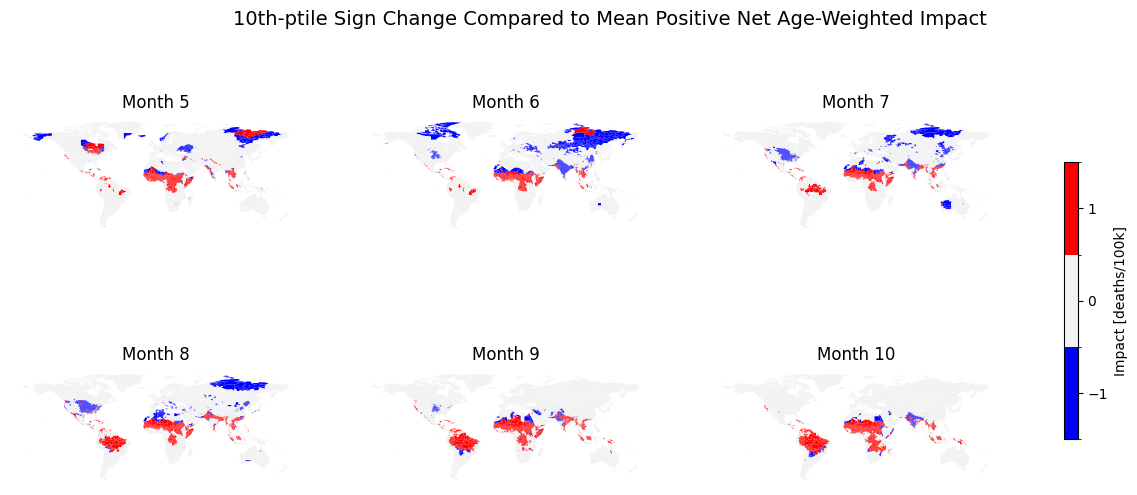

In [17]:
impact_dir_neg = False

da_impact = impact_gmfd
_polygons_num = compute_stats(da_impact, polygon=True)
gdf = _polygons_num

if impact_dir_neg:
    gdf['sign_diff'] = np.sign(gdf['mean']) * np.sign(gdf['p90']) * (gdf['mean'] < -1)
    cm = 'bwr_r'
else:
    gdf['sign_diff'] = np.sign(gdf['mean']) * np.sign(gdf['p10']) * (gdf['mean'] > 1)
    cm = 'bwr'

units = "deaths/100k" if rate else "num. deaths"

ptile = '90' if impact_dir_neg else '10'
neg = "Negative" if impact_dir_neg else "Positive"

fig = analysis_utils.plot_monthly(
    gdf,
    col='sign_diff',
    rate=rate,
    sup_title=f"{ptile}th-ptile Sign Change Compared to Mean {neg} Net Age-Weighted Impact",
    save_title=f'sign_change_{ptile}ptile_{neg}_mean_net_agwt.png',
    cm=cm,
)

## Temperature Range

In [12]:
#Temperature Anomalies
#Ranges in impacts line up (higher spread in impact, line up with larger spread in forecast)
da_forecast = forecast_gmfd['tas'].groupby('time.month').mean()
da_forecast = compute_stats(da_forecast, polygon = False)
da_impact = impact_gmfd
da_impact = compute_stats(da_impact, polygon = False)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


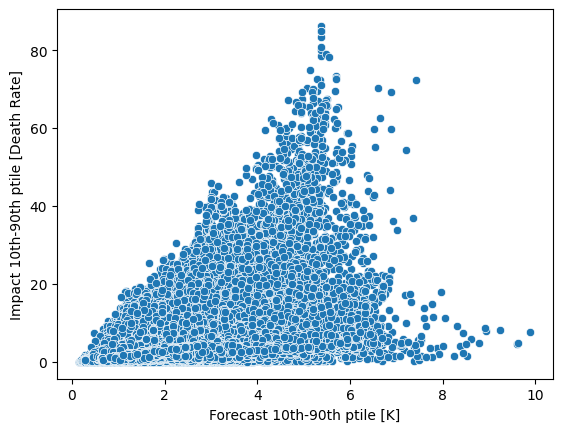

In [19]:
merged = xr.merge([da_impact['range'].rename('Impact_Range'), da_forecast['range'].rename('Forecast_Range')], join='inner')
#merged = xr.merge([da_impact['pct_spread'].rename('Impact'), da_forecast['pct_spread'].rename('Forecast')], join='inner')

mask = (merged['Impact_Range'] > .001).compute()
df = merged.where(mask, drop=True).to_dataframe().reset_index()

import seaborn as sns
sns.scatterplot(data=df, x='Forecast_Range', y='Impact_Range')
#plt.yscale('log')
plt.xlabel('Forecast 10th-90th ptile [K]')
plt.ylabel('Impact 10th-90th ptile [Death Rate]')

plt.savefig(f'impact_rate_tas_scatter_ensemble.png', dpi=600, bbox_inches="tight")


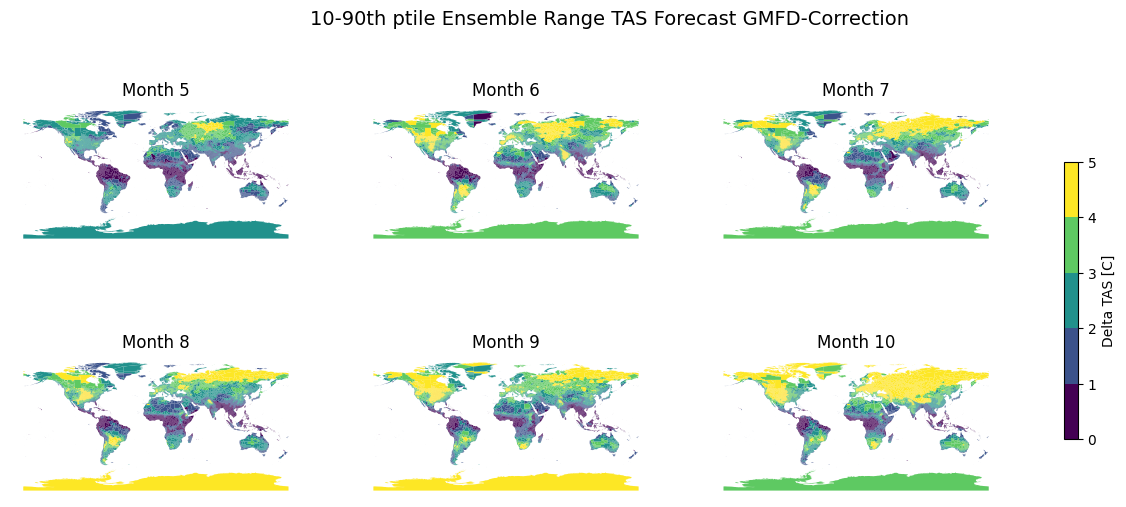

In [26]:
gdf = compute_stats(forecast_gmfd['tas'].groupby('time.month').mean(), polygon=True)
col = 'range'
absmax = gdf[col].abs().quantile(0.95)

fig = analysis_utils.plot_monthly(
    gdf,
    col=col,
    cm='viridis',
    vmin=0,
    vmax=absmax,
    sup_title="10-90th ptile Ensemble Range TAS Forecast GMFD-Correction",
    save_title='range_gmfd_tas_ensemble.png',
    cbar_label='Delta TAS [C]',
)

In [ ]:
gdf = compute_stats(forecast_gmfd['tas'].groupby('time.month').mean(), polygon = True)

# percent of mean (i.e. negative 10)
col = 'range'

absmax = gdf[col].abs().quantile(0.95)
norm = plt.Normalize(vmin=0, vmax=absmax)
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
months = sorted(gdf['month'].unique())

fig, axes = plt.subplots(2, 3, figsize=(16, 6))

for ax, month in zip(axes.flat, months):
    group = gdf[gdf['month'] == month]
    group.plot(
        column=col,
        legend=False,
        ax=ax,
        cmap="viridis",
        norm=norm,
        edgecolor='black',
        linewidth=0.03,
    )
    ax.set_title(f'Month {month}')
    ax.set_axis_off()

for ax in axes.flat[len(months):]:
    ax.set_axis_off()

fig.colorbar(sm, ax=axes.ravel().tolist(), location='right', shrink=0.6, label = 'Delta TAS [C]')

fig.suptitle(f"10-90th ptile Ensemble Range TAS Forecast GMFD-Correction", fontsize=14)
fig.savefig(f'range_gmfd_tas_ensemble.png', dpi=600, bbox_inches="tight")

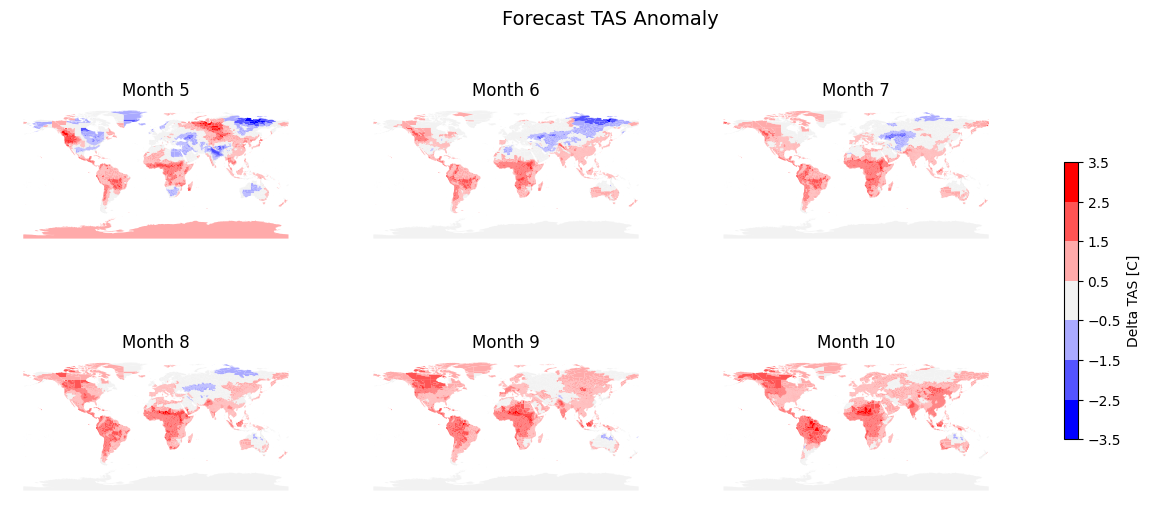

In [13]:
anomaly = forecast_gmfd['tas'].groupby('time.month').mean() - reanlysis_gmfd['tas'].groupby('time.month').mean()
gdf = compute_stats(anomaly, polygon=True)

fig = analysis_utils.plot_monthly(
    gdf,
    col='mean',
    cm='bwr',
    cbar_label='Delta TAS [C]',
    sup_title="Forecast TAS Anomaly",
    save_title='tas_anomaly.png',
)